# Assignment 6
Let's start doing Data Analysis for _Telia's Stock Prices_ from the year 2018.


In [306]:
# Write your information here!
student_name = 'Jayani Kothalawala'
student_id = 'AD9680'


## Assignment 6 Key Tasks

Let's describe the key tasks from _Assignment 6_.

### Data
We'll be working with Telia's stock prices from the year 2018, specifically time series data.

### Assignment 6-1: Data and Preprocessing
* Read Telia's stock prices for 2018.
* Parse the `'Date'` column and set it as the index.
* Keep relevant columns: `'Date', 'Opening price', 'High price', 'Low price', 'Closing price', 'Total volume'`.

### Assignment 6-2: Exploratory Data Analysis (EDA)
* Print the first ten days and sort data by `'Total volume'`.
* Create a new column `'High - Low'` representing price range.

### Assignment 6-3: Data Visualization
* Plot `'Low price'` and `'High price'`.
* Visualize using _rolling window_ and _exponentially weighted moving_ (ewm) average.

### Assignment 6-4: Outliers and Correlations
* Identify significant deviations using percentiles.
* Calculate _Pearson correlation coefficient_ and coefficient of determination (_R-squared_).

### Assignment 6-5: Regression Model
* Build a linear regression model.
* Visualize the model using seaborn's `regplot`.
* Perform error checking.


## Data and Preprocessing
### Data
Let's perform the necessary preprocessing for the data.
The dataset consists of **Telia stock prices** from 2018, i.e., it is _Time Series data_.

In [307]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Preprocessing

Firstly, let's read the data as it is, which is not the correct solution for this assignment, but it gives us some information in the `DataFrame`.

In [308]:
import pandas as pd

# Set the data source where the data is located
url_src = "data/telia2018.csv"

df = pd.read_csv(url_src,sep=";")
df.head()

,Date,Bid,Ask,Opening price,High price,Low price,Closing price,Average price,Total volume,Turnover,Trades,Unnamed: 11
0,2018-12-28,"4,078","4,083","4,00","4,117","3,995","4,076","4,083",988115,"4034300,94",1075,NaN
1,2018-12-27,"4,002","4,008","4,087","4,112","3,99","3,995","4,055",1195487,"4848035,58",1377,NaN
2,2018-12-21,"4,123","4,125","4,12","4,143","4,043","4,122","4,10",919570,"3770429,07",1096,NaN
3,2018-12-20,"4,169","4,174","4,151","4,186","4,119","4,163","4,162",941170,"3917348,22",1036,NaN
4,2018-12-19,"4,183","4,186","4,17","4,213","4,17","4,18","4,191",651864,"2732150,44",698,NaN


## Assignment 06-01. Read and sort data as a time series(1p)

Read the file, but set only a few columns of interest in the resulting `DataFrame`.
Set the `Date` column in the `DataFrame` as the `index`, so we get the `Date` as the `index` field.

Let's do the following tasks in this assignment:
* Parse the `Date` column into a date format.
* Set the `Date` column as the index in the DataFrame and remove the `Date` column from the DataFrame.
* The resulting `DataFrame` should have the following columns: `Date, Opening price, High price, Low price, Closing price, Total volume`, so remove other columns at this stage.

In [309]:
# TODO: Implement reading the file according to the following subtasks.
import pandas as pd
df["Date"] = pd.to_datetime(df["Date"])
df.set_index('Date', inplace=True)
df = df[["Opening price", "High price", "Low price", "Closing price", "Total volume"]]
df

,Opening price,High price,Low price,Closing price,Total volume
Date,,,,,
2018-12-28,"4,00","4,117","3,995","4,076",988115
2018-12-27,"4,087","4,112","3,99","3,995",1195487
2018-12-21,"4,12","4,143","4,043","4,122",919570
2018-12-20,"4,151","4,186","4,119","4,163",941170
2018-12-19,"4,17","4,213","4,17","4,18",651864
...,...,...,...,...,...
2018-01-08,"3,85","3,86","3,824","3,845",2151101
2018-01-05,"3,78","3,85","3,777","3,85",1306020
2018-01-04,"3,76","3,786","3,756","3,78",1540541


In [310]:
df.dtypes

Opening price    object
High price       object
Low price        object
Closing price    object
Total volume      int64
dtype: object

### Sorting the data
Let's do the following tasks in this assignment:
* Print the first ten days based on the `Date` value.
* Print the results sorted by the `Total volume` column.
* Create a new column `High - Low` that contains the difference between the highest and lowest prices.

In [311]:
# TODO: Print the first ten days based on the `Date` value
df = df.sort_index()
df = df.head(10)



In [312]:
# TODO: Print the results sorted by the `Total volume` column (largest value first).
df = df.sort_values(by="Total volume",ascending=True)
df

,Opening price,High price,Low price,Closing price,Total volume
Date,,,,,
2018-01-15,"3,831","3,835","3,812","3,823",972911
2018-01-05,"3,78","3,85","3,777","3,85",1306020
2018-01-04,"3,76","3,786","3,756","3,78",1540541
2018-01-02,"3,75","3,752","3,718","3,729",1717521
2018-01-03,"3,758","3,758","3,73","3,755",1823437
2018-01-09,"3,874","3,922","3,864","3,919",1970062
2018-01-10,"3,92","3,92","3,857","3,871",2070130
2018-01-08,"3,85","3,86","3,824","3,845",2151101
2018-01-12,"3,874","3,874","3,813","3,827",2671044


In [313]:
# TODO: Create a new column `High - Low` and print the DataFrame.
df["High-Low"] = df["High price"].str.replace(",", ".").astype(float) - df["Low price"].str.replace(",", ".").astype(float)
df

,Opening price,High price,Low price,Closing price,Total volume,High-Low
Date,,,,,,
2018-01-15,"3,831","3,835","3,812","3,823",972911,0.023
2018-01-05,"3,78","3,85","3,777","3,85",1306020,0.073
2018-01-04,"3,76","3,786","3,756","3,78",1540541,0.030
2018-01-02,"3,75","3,752","3,718","3,729",1717521,0.034
2018-01-03,"3,758","3,758","3,73","3,755",1823437,0.028
2018-01-09,"3,874","3,922","3,864","3,919",1970062,0.058
2018-01-10,"3,92","3,92","3,857","3,871",2070130,0.063
2018-01-08,"3,85","3,86","3,824","3,845",2151101,0.036
2018-01-12,"3,874","3,874","3,813","3,827",2671044,0.061


## Assignment 06-02. Data Visualization (1p)
Let's implement the following tasks in this assignment:
* Visualize time series data in your preferred way.
* Choose at least **two different** (or even more) figure types.
* Visualize the data using the `'Low price'` and `'High price'` columns.
* Visualize using, for example, the `rolling` operator, which gives an evenly weighted series.
* Visualize giving *more weight* to the most recent observations (using the `ewm` - exponentially weighted moving - operator). Such a series adapts more quickly to changes than a series with evenly weighted by `rolling` operator.

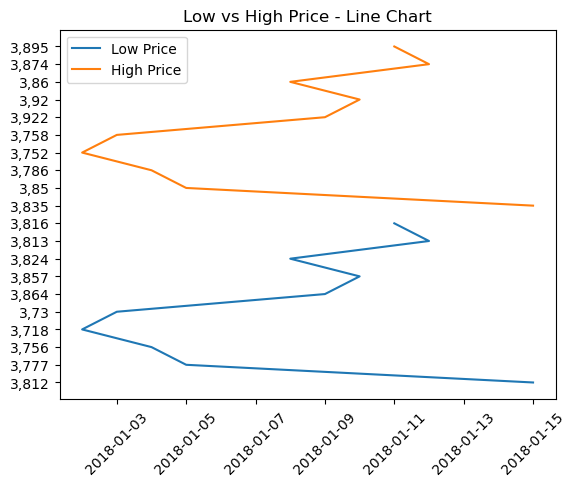

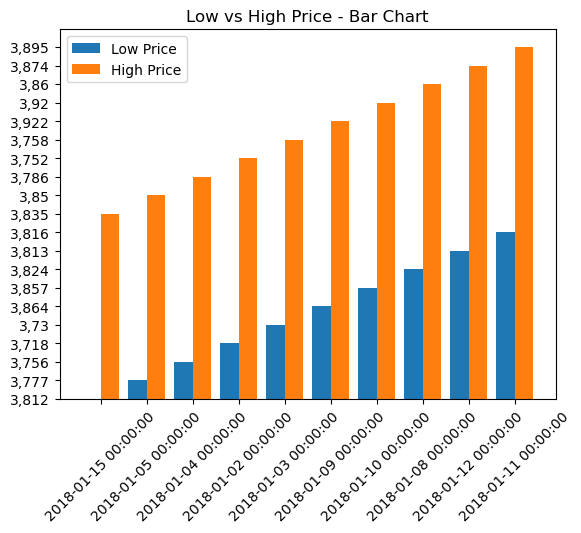

In [314]:
import matplotlib.pyplot as plt
# LINE CHART
plt.figure()
plt.plot(df.index, df["Low price"])
plt.plot(df.index, df["High price"])
plt.title("Low vs High Price - Line Chart")
plt.xticks(rotation=45)
plt.legend(["Low Price", "High Price"])
plt.show()

# bar plot
x = np.arange(len(df.index))   # numeric positions for each row
width = 0.4                    # bar width

plt.figure()
plt.bar(x - width/2, df["Low price"], width, label="Low Price")
plt.bar(x + width/2, df["High price"], width, label="High Price")

plt.title("Low vs High Price - Bar Chart")
plt.xticks(x, df.index, rotation=45)
plt.legend()
plt.show()



A figure with a Rolling window of `n` days.

            Opening price  High price  Low price  Closing price  Total volume  \
Date                                                                            
2018-01-15          3.831       3.835      3.812          3.823        972911   
2018-01-05          3.780       3.850      3.777          3.850       1306020   
2018-01-04          3.760       3.786      3.756          3.780       1540541   
2018-01-02          3.750       3.752      3.718          3.729       1717521   
2018-01-03          3.758       3.758      3.730          3.755       1823437   
2018-01-09          3.874       3.922      3.864          3.919       1970062   
2018-01-10          3.920       3.920      3.857          3.871       2070130   
2018-01-08          3.850       3.860      3.824          3.845       2151101   
2018-01-12          3.874       3.874      3.813          3.827       2671044   
2018-01-11          3.895       3.895      3.816          3.863       2735266   

            High-Low  Closi

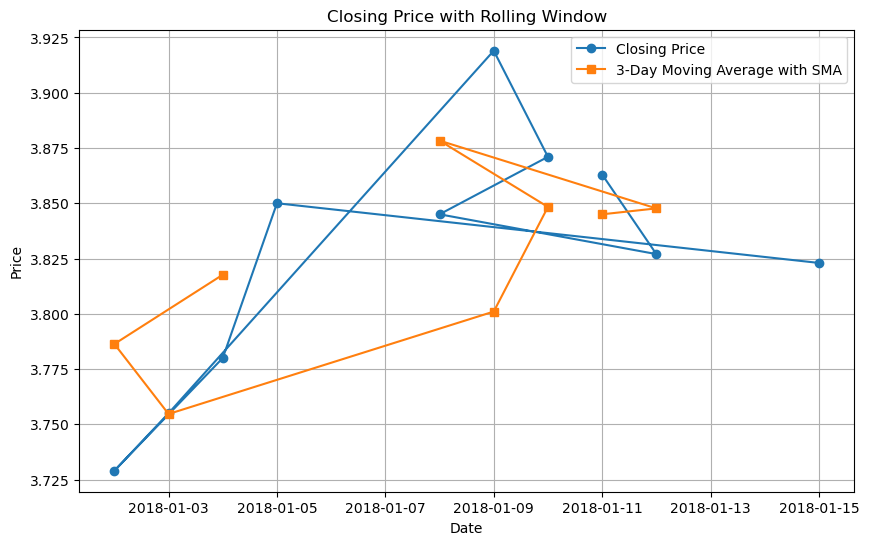

In [315]:
# TODO: Use the Rolling Window operator in visualization
cols = ['Opening price', 'High price', 'Low price', 'Closing price']

# Remove commas and convert to numeric
for col in cols:
    df[col] = df[col].str.replace(',', '.').astype(float)
n=3
df['Closing_SMA3'] = df['Closing price'].rolling(window=n).mean()
print(df)
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Closing price'], marker='o', label='Closing Price')
plt.plot(df.index, df['Closing_SMA3'], marker='s', label='3-Day Moving Average with SMA')
plt.title('Closing Price with Rolling Window')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


### Weighting Recent Observations
Often, methods are used where *more weight* is given to recent observations.
Such a series adapts more quickly to changes than a series with evenly weighted by the `rolling` operator.

The `ewm` (*exponentially weighted moving*) operator provides such a series, where the `span` parameter determines the window size.

            Opening price  High price  Low price  Closing price  Total volume  \
Date                                                                            
2018-01-15          3.831       3.835      3.812          3.823        972911   
2018-01-05          3.780       3.850      3.777          3.850       1306020   
2018-01-04          3.760       3.786      3.756          3.780       1540541   
2018-01-02          3.750       3.752      3.718          3.729       1717521   
2018-01-03          3.758       3.758      3.730          3.755       1823437   
2018-01-09          3.874       3.922      3.864          3.919       1970062   
2018-01-10          3.920       3.920      3.857          3.871       2070130   
2018-01-08          3.850       3.860      3.824          3.845       2151101   
2018-01-12          3.874       3.874      3.813          3.827       2671044   
2018-01-11          3.895       3.895      3.816          3.863       2735266   

            High-Low  Closi

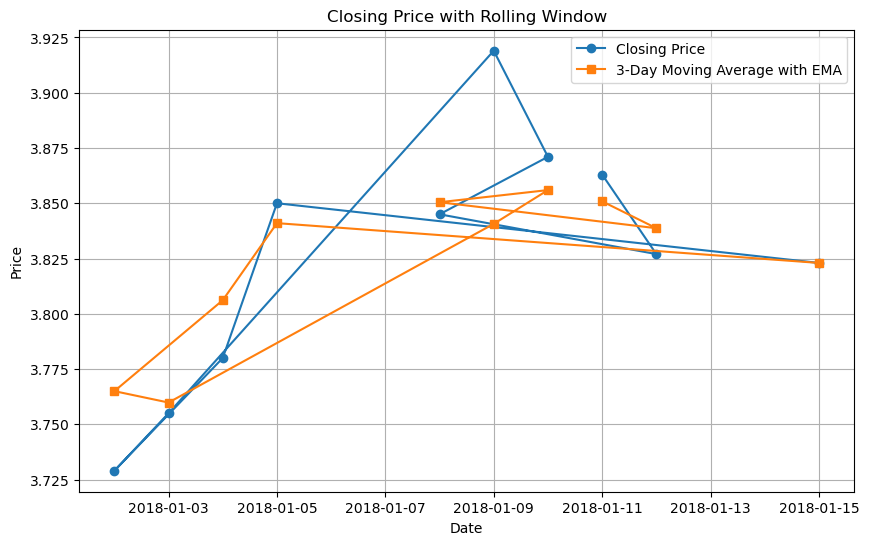

In [316]:
# TODO: Use the ewm operator in visualization

df['Closing_EMA3'] = df['Closing price'].ewm(span=3).mean()
print(df)
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Closing price'], marker='o', label='Closing Price')
plt.plot(df.index, df['Closing_EMA3'], marker='s', label='3-Day Moving Average with EMA')
plt.title('Closing Price with Rolling Window')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


## Assignment 06-03. Outliers and Correlations (1p)

Let's do the following tasks in this assignment:

* Check for *significant deviations* in each numerical column in the data. Significantly deviating values can be replaced if needed.
* Use the `2%` and `98%` percentiles of the data to identify significant deviations.
* Also, calculate the **Pearson correlation coefficient** and **coefficient of determination (R-squared)**.

In [317]:
# TODO: Calculate deviations (2% - 98%)
numerical_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical columns:", numerical_cols)
# Define percentiles
lower_percentile = 0.02
upper_percentile = 0.98


for col in numerical_cols:
    lower = df[col].quantile(lower_percentile)
    upper = df[col].quantile(upper_percentile)
    print(f"{col}: 2%={lower}, 98%={upper}")
    
   
    df[col] = df[col].clip(lower, upper)
    
# Correlation matrix
corr_matrix = df[numerical_cols].corr(method='pearson')
print("Pearson Correlation Matrix:")
print(corr_matrix)

x = df['Opening price']
y = df['Closing price']
# Pearson correlation coefficient
r = x.corr(y)
print("Pearson r:", r)

# Coefficient of determination (R-squared)
r_squared = r**2
print("R-squared:", r_squared)
r_squared_matrix = corr_matrix**2
print("R-squared matrix:")
print(r_squared_matrix)


Numerical columns: Index(['Opening price', 'High price', 'Low price', 'Closing price',
       'Total volume', 'High-Low', 'Closing_SMA3', 'Closing_EMA3'],
      dtype='object')
Opening price: 2%=3.75144, 98%=3.9154999999999998
High price: 2%=3.7530799999999997, 98%=3.92164
Low price: 2%=3.72016, 98%=3.86274
Closing price: 2%=3.73368, 98%=3.91036
Total volume: 2%=1032870.62, 98%=2723706.04
High-Low: 2%=0.023900000000000112, 98%=0.07792000000000014
Closing_SMA3: 2%=3.7591, 98%=3.874133333333334
Closing_EMA3: 2%=3.760767741935484, 98%=3.855043435010506
Pearson Correlation Matrix:
               Opening price  High price  Low price  Closing price  \
Opening price       1.000000    0.923426   0.916336       0.808855   
High price          0.923426    1.000000   0.957069       0.962539   
Low price           0.916336    0.957069   1.000000       0.929300   
Closing price       0.808855    0.962539   0.929300       1.000000   
Total volume        0.608775    0.448443   0.341743       0.286581

Let's calculate:
* **Pearson correlation coefficient**
* **Coefficient of determination**
The goal is to identify _significant correlations_ between different columns of the data.

### Dependency between two variables

The dependency between two quantitative variables is examined using a **scatter plot** and the **correlation coefficient**.

### Scatter Plot

The **scatter plot** provides a quick view of the distribution of values for two variables.
* Usually interested in whether large values of `x` are associated with large or small values of `y`.
Whether there is a correlation, or if `y` values are random, indicating no significant correlation.

In [318]:
# TODO: Calculate the correlation of Opening price to Closing price

import pandas as pd

# Calculate Pearson correlation
r = df['Opening price'].corr(df['Closing price'])
print("Pearson correlation (Opening vs Closing):", r)

# Calculate R-squared
r_squared = r**2
print("R-squared (Opening vs Closing):", r_squared)

Pearson correlation (Opening vs Closing): 0.8088551367459483
R-squared (Opening vs Closing): 0.6542466322403068


In [319]:
# TODO: Calculate the correlation of Opening price to other columns

import pandas as pd

# Pearson correlation of 'Opening price' with all other columns
correlations = df.corr()['Opening price']
print("Correlation of Opening price with other columns:")
print(correlations)


Correlation of Opening price with other columns:
Opening price    1.000000
High price       0.923426
Low price        0.916336
Closing price    0.808855
Total volume     0.608775
High-Low         0.580977
Closing_SMA3     0.696503
Closing_EMA3     0.816414
Name: Opening price, dtype: float64


### Correlations
Correlations between all columns.

In [320]:
# TODO: Calculate correlations between all columns

import pandas as pd

# Calculate correlation matrix
corr_matrix = df.corr()
print("Correlation matrix between all columns:")
print(corr_matrix)


Correlation matrix between all columns:
               Opening price  High price  Low price  Closing price  \
Opening price       1.000000    0.923426   0.916336       0.808855   
High price          0.923426    1.000000   0.957069       0.962539   
Low price           0.916336    0.957069   1.000000       0.929300   
Closing price       0.808855    0.962539   0.929300       1.000000   
Total volume        0.608775    0.448443   0.341743       0.286581   
High-Low            0.580977    0.713692   0.480131       0.664993   
Closing_SMA3        0.696503    0.638887   0.647009       0.560278   
Closing_EMA3        0.816414    0.915346   0.874187       0.897713   

               Total volume  High-Low  Closing_SMA3  Closing_EMA3  
Opening price      0.608775  0.580977      0.696503      0.816414  
High price         0.448443  0.713692      0.638887      0.915346  
Low price          0.341743  0.480131      0.647009      0.874187  
Closing price      0.286581  0.664993      0.560278      

_Coefficient of determination_, often denoted as **R^2** (pronounced _R-squared_), is a statistical measure that represents
the proportion of the variance in the dependent variable that is predictable from the independent variables.

In [321]:
# TODO: Calculate the Coefficient of determination
# Correlation matrix
corr_matrix = df.corr()

# R-squared matrix
r_squared_matrix = corr_matrix**2

print("R-squared matrix:")
print(r_squared_matrix)


R-squared matrix:
               Opening price  High price  Low price  Closing price  \
Opening price       1.000000    0.852715   0.839672       0.654247   
High price          0.852715    1.000000   0.915981       0.926481   
Low price           0.839672    0.915981   1.000000       0.863598   
Closing price       0.654247    0.926481   0.863598       1.000000   
Total volume        0.370607    0.201102   0.116788       0.082129   
High-Low            0.337534    0.509357   0.230526       0.442216   
Closing_SMA3        0.485116    0.408177   0.418621       0.313912   
Closing_EMA3        0.666532    0.837858   0.764203       0.805889   

               Total volume  High-Low  Closing_SMA3  Closing_EMA3  
Opening price      0.370607  0.337534      0.485116      0.666532  
High price         0.201102  0.509357      0.408177      0.837858  
Low price          0.116788  0.230526      0.418621      0.764203  
Closing price      0.082129  0.442216      0.313912      0.805889  
Total volum

`HeatMap` is a 2-dimensional matrix plot that gives visualization of numerical values in the form of cells.
* The colors in the `HeatMap` chart represent the relationship of the values with the `DataFrame`, making it easy to spot patterns in the data.
* Heatmaps are particularly useful for visualizing the magnitude of a phenomenon in two dimensions.

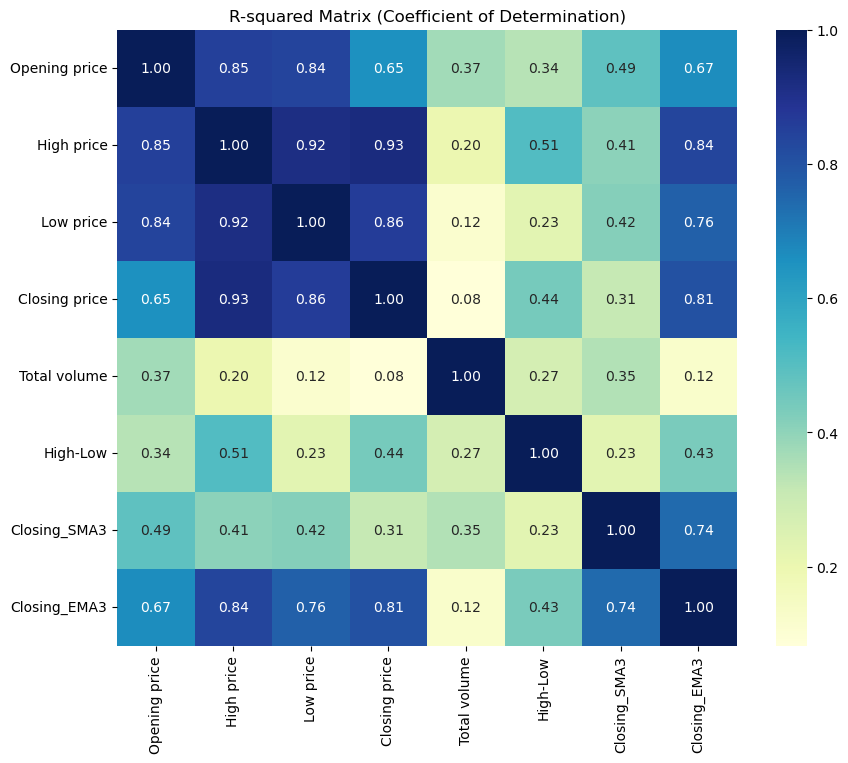

In [322]:
# TODO: Visualization: Correlations and/or Coefficient of determination as a HeatMap image
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(r_squared_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("R-squared Matrix (Coefficient of Determination)")
plt.show()


## Assignment 06-04. Regression Model (1p)

Let's do the following tasks in this assignment:
* Build a **Linear Regression** model from the data.
* The linear model for dependence can be obtained by importing the `LinearRegression` class from the `sklearn.linear_model` library.
* Choose the target variable (`y`) and explanatory variable (`x`) from the data.
* Visualization can be done using the `regplot` method from the `seaborn` library.
* Error checking using metrics including _Mean Squared Error_ (_MSE_), _R-squared_, _Mean Absolute Error_ (MAE) etc. (see information before implementing from [https://en.wikipedia.org/wiki/Mean_absolute_error](https://en.wikipedia.org/wiki/Mean_absolute_error)).

# RegPlot

Plot data and a linear regression model fit.

Intercept: 0.5291597461157709
Slope: 0.8600559371447711


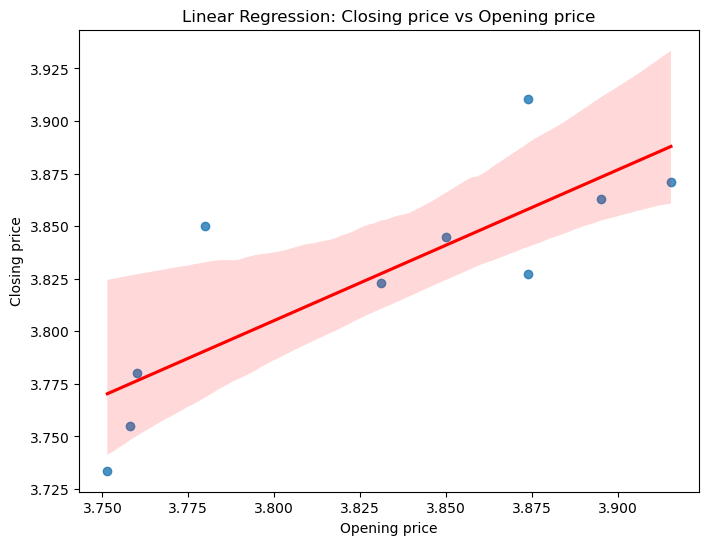

Mean Squared Error (MSE): 0.0030
Mean Absolute Error (MAE): 0.0519
R-squared (R²): -21.8098


In [323]:
# TODO: Visualization of the regression model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Explanatory variable (independent)
X = df[['Opening price']]  # keep it as 2D array for sklearn

# Target variable (dependent)
y = df['Closing price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print model coefficients
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
plt.figure(figsize=(8,6))
sns.regplot(x='Opening price', y='Closing price', data=df, line_kws={"color":"red"})
plt.title("Linear Regression: Closing price vs Opening price")
plt.show()


# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")


## Linear model for dependence

The linear model for dependence is obtained by importing the `LinearRegression` class from the `sklearn.linear_model` library.
* Choose the **explanatory variables (x)**.
* Choose the **target variable (y)**.

In [324]:
from sklearn.linear_model import LinearRegression

# TODO: Regression Model: Linear model for selected columns.
# Features (explanatory variables)
X = df[['Opening price', 'High price', 'Low price', 'Total volume']]

# Target variable
y = df['Closing price']
model = LinearRegression()

model.fit(X, y)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Optional: pair feature names with coefficients
coef_dict = dict(zip(X.columns, model.coef_))
print("Feature coefficients:", coef_dict)

# TODO: Justify the choice as well.
y_pred = model.predict(X)

# Compare predicted vs actual
comparison = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
print(comparison)


Intercept: 0.3861344674317091
Coefficients: [-5.67593505e-01  1.06538094e+00  3.98652158e-01  1.39262809e-09]
Feature coefficients: {'Opening price': -0.5675935048698322, 'High price': 1.0653809362412696, 'Low price': 0.3986521575184603, 'Total volume': 1.392628087478384e-09}
             Actual  Predicted
Date                          
2018-01-15  3.82300   3.818520
2018-01-05  3.85000   3.849876
2018-01-04  3.78000   3.784998
2018-01-02  3.73368   3.740743
2018-01-03  3.75500   3.746332
2018-01-09  3.91036   3.907951
2018-01-10  3.87100   3.880500
2018-01-08  3.84500   3.840711
2018-01-12  3.82700   3.838343
2018-01-11  3.86300   3.850066


## Assignment 06-05. Result Analysis (1p)

Let's interpret and analyze the results you have obtained in Assignments **6.1 - 6.4** in words.
* Preprocessing - I first imported dataset and converted all numeric columns from string type to floating point numbers for calculations. Commas were removed. Outliers were identified using 2% and 98% percentiles and values adjusted between them. To smooth the closing price calculated rolling window operator and ewm.
* Visualization - Used line charts and heatmaps for data visualization. 
* Correlation - Used Pearson correlation and R-squared to show the correlation between closing price and opening price vs opening price to other numeric columns. In Pearson correlation the High price and Closing price had a strong positive correlation of 0.96, indicating that daily high prices are closely related to closing prices. The R squared showed that 92% of the variance in Closing price can be explained by the High price.
* Time series data - Time series data calculated with rolling window operator and ewm. By applying rolling window operators, I observed smooth trends in closing prices and reduced short-term fluctuations. The 3-day rolling average highlighted minor fluctuations in the prices, while the 3-day EMA emphasized the latest price movements more clearly, making it easier to detect small trends.
* Regression model - A linear regression model was fitted with Opening price, High price, Low price, and Total volume as explanatory variables and Closing price as the target variable. The model coefficients indicate the contribution of each variable to the closing price. Linear model plays a general trend in this dataset.

Write the answer verbally. Note that you can use tables and figures to clarify your answer.

### Assignment 06-06 - Extra Assignments (0p)
These are not graded tasks, but you can do them to improve your own skills.

If you have a strong motivation to do more data analysis tasks, you can consider the following:
* Extra Assignment: Build another regression model from the data.
* Extra Assignment: How to visualize regression errors?
* Extra Assignment: Can you build a classification model based on this dataset?
